[np.float64(0.40419935258780576), np.float64(13.21569867593533), np.float64(11.456686427802369), np.float64(11.988111854965771)]


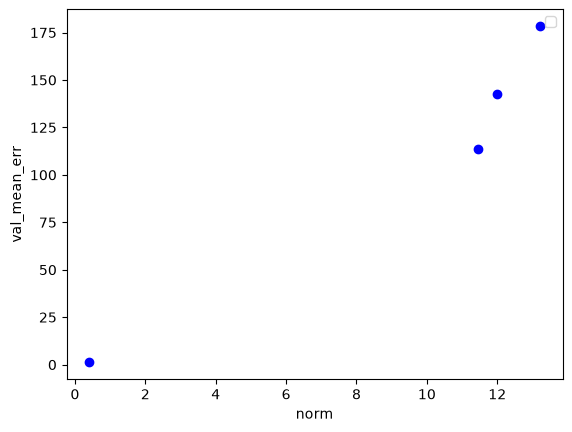

In [13]:
import numpy as np
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import util



def generate_plot(betas, X, Y, X_val, Y_val, save_path):
    """绘制验证误差与参数范数的关系散点图。

    参数：
        betas: 由 NumPy 数组组成的列表，每个数组代表一个解
        X, Y: 训练集的特征与标签
        X_val, Y_val: 验证集的特征与标签
        save_path: 图像保存路径
    """
    # 检查每个解的训练误差是否近似为零，即 X @ b ≈ Y。
    
    for b in betas:
        assert(np.allclose(X.dot(b), Y))

    # 分别计算各个解的 L2 范数和验证集均方误差。
    val_err = []
    norms = []
    for i in range(len(betas)):
        val_err.append(np.mean((X_val.dot(betas[i]) - Y_val) ** 2))
        norms.append(np.linalg.norm(betas[i]))

    print(norms)
    # 比较参数范数与验证误差的关系。
    util.plot_points(norms, val_err, save_path)

def linear_model_main():
    save_path_linear = "implicitreg_linear"
    
    train_path = 'ds1_train.csv'
    valid_path = 'ds1_valid.csv'
    X, Y = util.load_dataset(train_path)
    X_val, Y_val = util.load_dataset(valid_path)
    # 假设模型不需要偏置项。
    
    beta_0 = None
    # *** 在此开始编写代码 ***
    # beta_0 是满足 X @ beta_0 = Y 的最小 L2 范数解。
    beta_0=util.train(X,Y)
    # *** 代码编写结束 ***
    
    assert(np.allclose(X.dot(beta_0), Y))
    
    # ns 的每一列都是零空间的一个基向量，与 X 的所有行向量正交。
    # 使用前可查看 ns.shape，列数就是零空间的维数。
    ns = null_space(X)
    # 本例 ns.shape 为 (200, 160)，因此 rank(X) = 200 - 160 = 40。

    # *** 在此开始编写代码 ***
    # 对零空间基向量作随机线性组合，得到满足 X @ zeta ≈ 0 的扰动。
    zetas=[ns @ np.random.randn(ns.shape[1]) for _ in range(3)]
    # beta_0 + zeta 仍拟合训练集，但参数范数和验证误差可能改变。
    generate_plot([beta_0]+[beta_0+ zeta for zeta in zetas],X,Y,X_val,Y_val,save_path_linear)
    # *** 代码编写结束 ***

if __name__ == '__main__':
    linear_model_main()